# 🛒 Sentiment Analysis on Amazon Food Reviews
**Internship Project — Week 1**  
**Submitted by:** Varssha G 
**Date:** May 2026

---

## 📦 Task 1 — Data Loading & Exploration

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
import warnings, os
warnings.filterwarnings('ignore')
os.makedirs('charts', exist_ok=True)

# Load first 5000 rows
df_full = pd.read_csv('Reviews.csv', nrows=5000)
print("Shape of dataset:", df_full.shape)
print("\nColumn names:", list(df_full.columns))
df_full.head(10)

Shape of dataset: (4984, 4)

Column names: ['Text', 'Score', 'Polarity', 'Sentiment']


,Text,Score,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive
5,I got a wild hair for taffy and ordered this f...,4,0.257407,Positive
6,This saltwater taffy had great flavors and was...,5,0.250833,Positive
7,This taffy is so good. It is very soft and ch...,5,0.486000,Positive
8,Right now I'm mostly just sprouting this so my...,5,0.428571,Positive
9,This is a very healthy dog food. Good for thei...,5,0.450000,Positive


In [5]:
print("Review text column : Text")
print("Rating column      : Score (1 to 5 stars)")
print("\nSample review:")
print(df_full['Text'].iloc[0])

Review text column : Text
Rating column      : Score (1 to 5 stars)

Sample review:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.


## 🧹 Task 2 — Data Cleaning

In [6]:
df = df_full[['Text', 'Score']].copy()
df.dropna(subset=['Text'], inplace=True)
df.drop_duplicates(subset=['Text'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Original rows  : 5000")
print(f"After cleaning : {len(df)} rows")
print(f"Removed        : {5000 - len(df)} rows (nulls + duplicates)")
df.head()

Original rows  : 5000
After cleaning : 4984 rows
Removed        : 16 rows (nulls + duplicates)


,Text,Score
0,I have bought several of the Vitality canned d...,5
1,Product arrived labeled as Jumbo Salted Peanut...,1
2,This is a confection that has been around a fe...,4
3,If you are looking for the secret ingredient i...,2
4,Great taffy at a great price. There was a wid...,5


## 🤖 Task 3 — Sentiment Analysis using TextBlob

In [7]:
df['Polarity'] = df['Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

def label_sentiment(score):
    if score > 0:   return 'Positive'
    elif score < 0: return 'Negative'
    else:           return 'Neutral'

df['Sentiment'] = df['Polarity'].apply(label_sentiment)

counts = df['Sentiment'].value_counts()
total  = len(df)
print("Sentiment Counts:\n", counts)
print(f"\nPositive : {counts.get('Positive',0)/total*100:.1f}%")
print(f"Negative : {counts.get('Negative',0)/total*100:.1f}%")
print(f"Neutral  : {counts.get('Neutral',0)/total*100:.1f}%")
df.head(10)

Sentiment Counts:
 Sentiment
Positive    4403
Negative     501
Neutral       80
Name: count, dtype: int64

Positive : 88.3%
Negative : 10.1%
Neutral  : 1.6%


,Text,Score,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive
5,I got a wild hair for taffy and ordered this f...,4,0.257407,Positive
6,This saltwater taffy had great flavors and was...,5,0.250833,Positive
7,This taffy is so good. It is very soft and ch...,5,0.486000,Positive
8,Right now I'm mostly just sprouting this so my...,5,0.428571,Positive
9,This is a very healthy dog food. Good for thei...,5,0.450000,Positive


## 📊 Task 4 — Visualizations

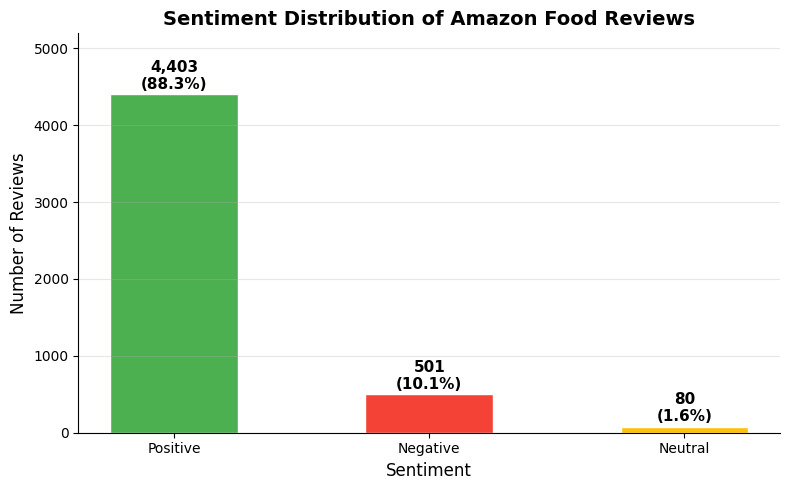

Chart 1 saved!


In [8]:
# Chart 1: Bar Chart
colors = {'Positive':'#4CAF50','Neutral':'#FFC107','Negative':'#F44336'}
counts = df['Sentiment'].value_counts()
fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(counts.index, counts.values,
              color=[colors[s] for s in counts.index], edgecolor='white', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
            f'{val:,}\n({val/total*100:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Sentiment Distribution of Amazon Food Reviews', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment', fontsize=12); ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_ylim(0, counts.max()*1.18)
ax.spines[['top','right']].set_visible(False); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('charts/bar_chart.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 1 saved!")

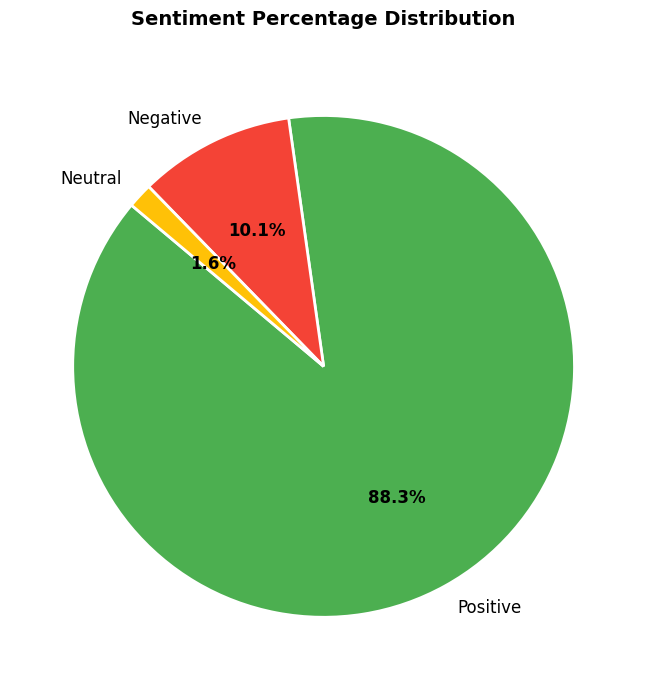

Chart 2 saved!


In [9]:
# Chart 2: Pie Chart
fig, ax = plt.subplots(figsize=(7,7))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=[colors[s] for s in counts.index], startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2), textprops={'fontsize':12})
for at in autotexts: at.set_fontsize(12); at.set_fontweight('bold')
ax.set_title('Sentiment Percentage Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout(); plt.savefig('charts/pie_chart.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 2 saved!")

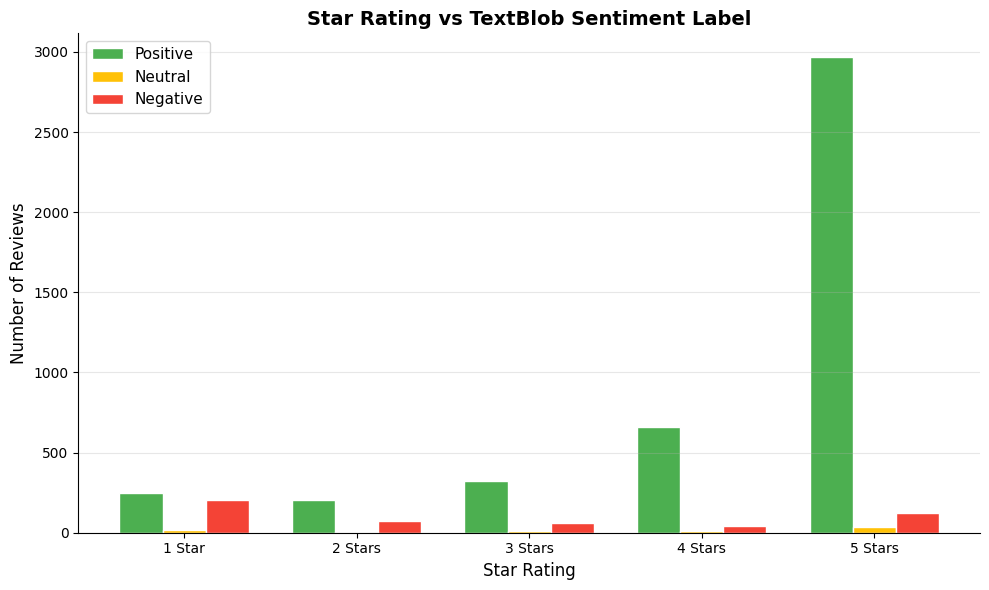

Chart 3 saved!


In [10]:
# Chart 3: Star Rating vs Sentiment
rating_sent = df.groupby(['Score','Sentiment']).size().unstack(fill_value=0)
for col in ['Positive','Neutral','Negative']:
    if col not in rating_sent.columns: rating_sent[col] = 0
rating_sent = rating_sent[['Positive','Neutral','Negative']]

fig, ax = plt.subplots(figsize=(10,6))
x = range(1,6); width = 0.25; offset = [-width, 0, width]
for i, (sent, col) in enumerate(zip(['Positive','Neutral','Negative'],['#4CAF50','#FFC107','#F44336'])):
    vals = [rating_sent.loc[r, sent] if r in rating_sent.index else 0 for r in range(1,6)]
    ax.bar([xi+offset[i] for xi in x], vals, width, label=sent, color=col, edgecolor='white')
ax.set_title('Star Rating vs TextBlob Sentiment Label', fontsize=14, fontweight='bold')
ax.set_xlabel('Star Rating', fontsize=12); ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_xticks(list(x)); ax.set_xticklabels(['1 Star','2 Stars','3 Stars','4 Stars','5 Stars'])
ax.legend(fontsize=11); ax.spines[['top','right']].set_visible(False); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig('charts/rating_vs_sentiment.png', dpi=150, bbox_inches='tight'); plt.show()
print("Chart 3 saved!")

## 📝 Task 5 — Insights & Summary

In [11]:
print("""
===== INSIGHTS & SUMMARY =====

1. POSITIVE REVIEWS: 88.3% of Amazon food reviews are Positive, showing
   that customers are largely satisfied with the products they purchase.

2. NEGATIVE COMPLAINTS: Negative reviews commonly mention issues with flavor,
   snacks not meeting expectations, and dissatisfaction with product 
   descriptions being misleading compared to what was delivered.

3. SURPRISING FINDING: Even 1-star and 2-star reviews sometimes get classified
   as 'Positive' by TextBlob. Customers use polite language even when
   complaining — showing that star ratings and text sentiment don't always align.

4. BUSINESS RECOMMENDATION: The business should closely monitor the ~10% of
   negative reviews and identify recurring product issues (especially flavor
   and packaging), as fixing these could convert unhappy customers into
   loyal repeat buyers and improve overall star ratings.
""")


===== INSIGHTS & SUMMARY =====

1. POSITIVE REVIEWS: 88.3% of Amazon food reviews are Positive, showing
   that customers are largely satisfied with the products they purchase.

2. NEGATIVE COMPLAINTS: Negative reviews commonly mention issues with flavor,
   snacks not meeting expectations, and dissatisfaction with product 
   descriptions being misleading compared to what was delivered.

3. SURPRISING FINDING: Even 1-star and 2-star reviews sometimes get classified
   as 'Positive' by TextBlob. Customers use polite language even when
   complaining — showing that star ratings and text sentiment don't always align.

4. BUSINESS RECOMMENDATION: The business should closely monitor the ~10% of
   negative reviews and identify recurring product issues (especially flavor
   and packaging), as fixing these could convert unhappy customers into
   loyal repeat buyers and improve overall star ratings.

